🔴 Overfitting Check:
Train RMSE: 3.218325866275131e-16
Test RMSE : 0.7028289572288925
Cross Validation RMSE: 0.724213776329786
Best Parameters: {'max_depth': 10, 'min_samples_split': 10}

📊 Tuned Model Performance:
RMSE: 0.6453626634464059
R² : 0.6821656640892819

🏆 Final Comparison:
                 Model      RMSE  R2 Score
0    Linear Regression  0.745581  0.575788
1     Ridge Regression  0.745557  0.575816
2  Tuned Decision Tree  0.645363  0.682166

✅ Best Model:
Model       Tuned Decision Tree
RMSE                   0.645363
R2 Score               0.682166
Name: 2, dtype: object


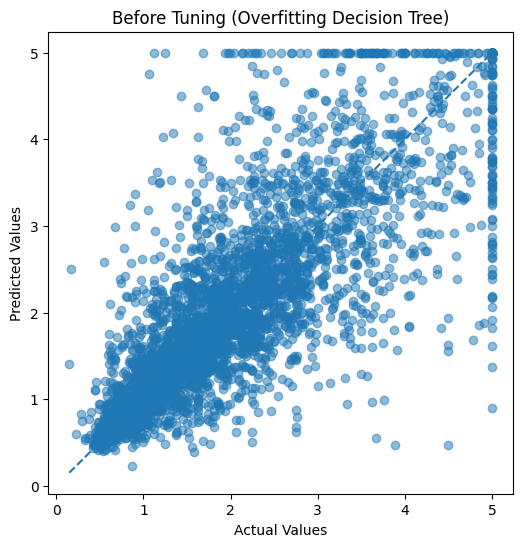

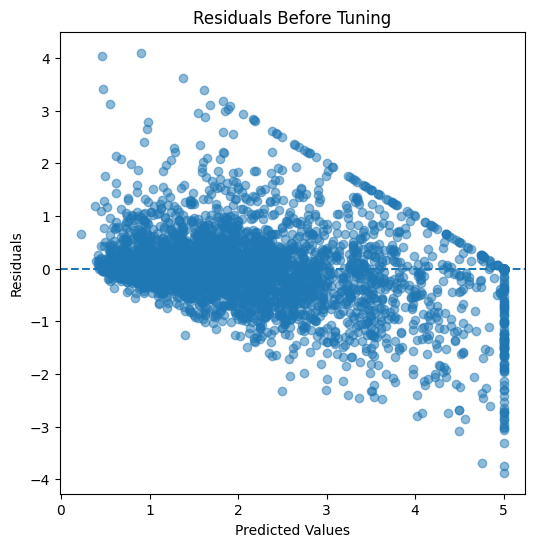

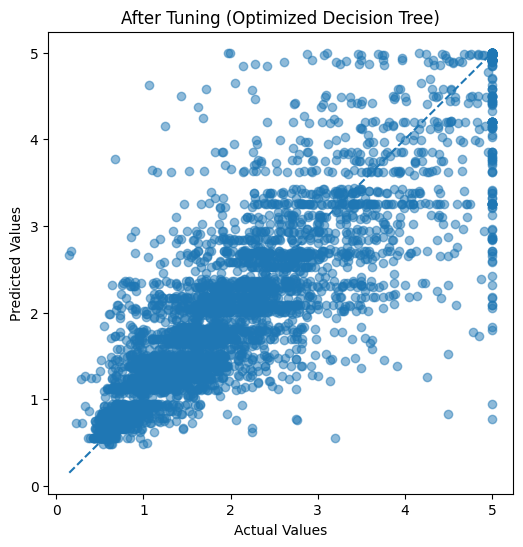

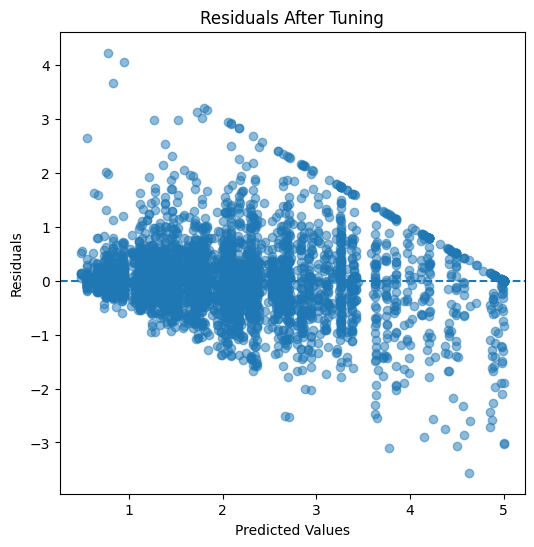

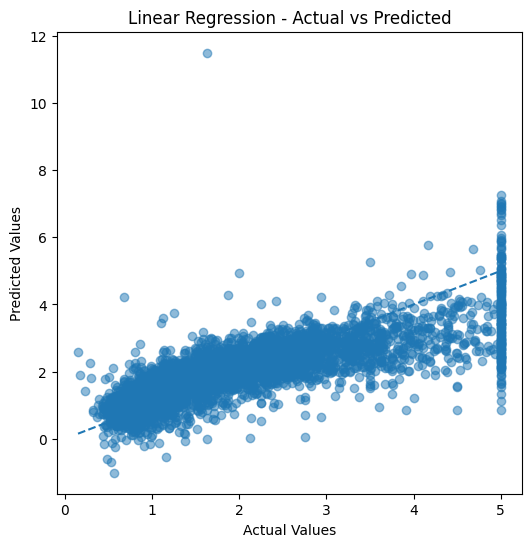

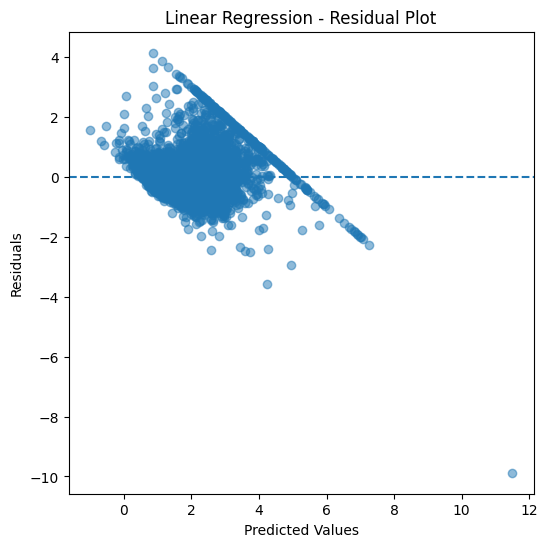

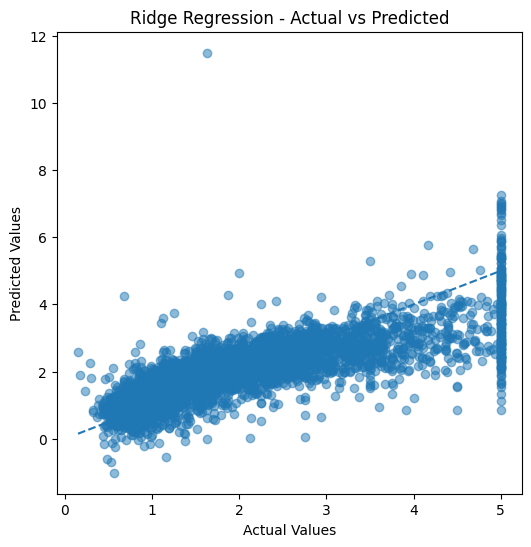

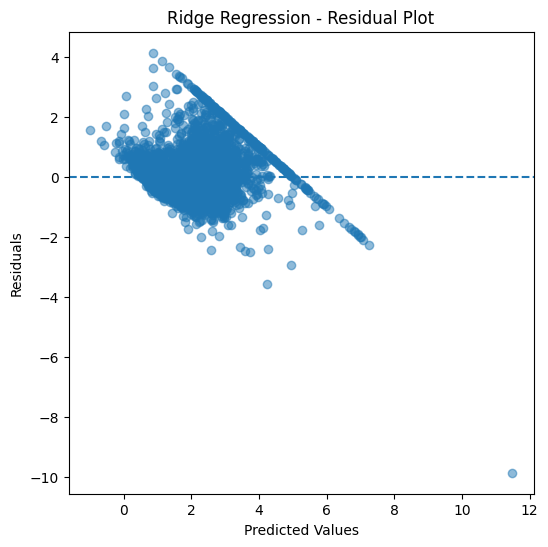

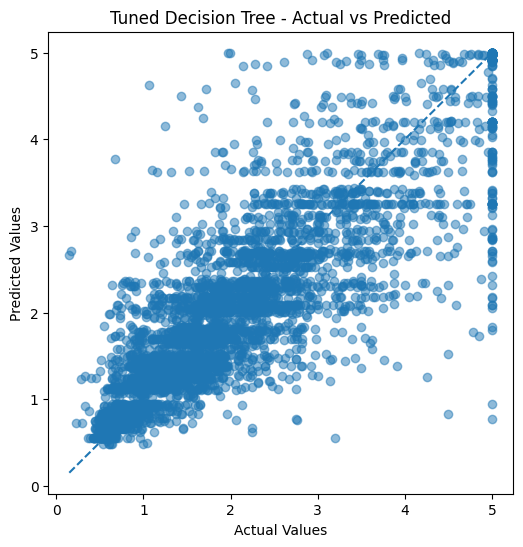

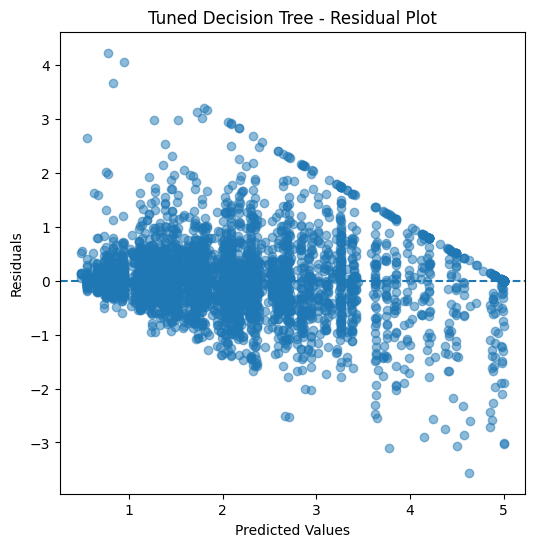

In [6]:
# ======================
# 1. Imports
# ======================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_squared_error, r2_score

# ======================
# 2. Load Dataset
# ======================
data = fetch_california_housing(as_frame=True)
df = data.frame

X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

# ======================
# 3. Train-Test Split
# ======================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ======================
# 4. Feature Scaling (No Data Leakage)
# ======================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ======================
# 5. Overfitting Check (Before Tuning)
# ======================
tree_overfit = DecisionTreeRegressor(random_state=42)
tree_overfit.fit(X_train, y_train)

train_pred = tree_overfit.predict(X_train)
test_pred = tree_overfit.predict(X_test)

print("🔴 Overfitting Check:")
print("Train RMSE:", np.sqrt(mean_squared_error(y_train, train_pred)))
print("Test RMSE :", np.sqrt(mean_squared_error(y_test, test_pred)))

# ======================
# 6. Cross Validation
# ======================
cv_scores = cross_val_score(
    tree_overfit, X_train, y_train,
    scoring="neg_root_mean_squared_error",
    cv=5
)

cv_rmse = -cv_scores.mean()
print("Cross Validation RMSE:", cv_rmse)

# ======================
# 7. Hyperparameter Tuning
# ======================
param_grid = {
    "max_depth": [3, 5, 7, 10],
    "min_samples_split": [2, 5, 10]
}

grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

# ======================
# 8. Evaluate Tuned Model
# ======================
best_tree = grid.best_estimator_

y_pred_best = best_tree.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2 = r2_score(y_test, y_pred_best)

print("\n📊 Tuned Model Performance:")
print("RMSE:", rmse)
print("R² :", r2)

# ======================
# 9. Train Other Models
# ======================
lr = LinearRegression()
lr.fit(X_train, y_train)

ridge = Ridge()
ridge.fit(X_train, y_train)

# ======================
# 10. Evaluate All Models
# ======================
lr_rmse = np.sqrt(mean_squared_error(y_test, lr.predict(X_test)))
lr_r2 = r2_score(y_test, lr.predict(X_test))

ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge.predict(X_test)))
ridge_r2 = r2_score(y_test, ridge.predict(X_test))

# ======================
# 11. Comparison Table
# ======================
results = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression", "Tuned Decision Tree"],
    "RMSE": [lr_rmse, ridge_rmse, rmse],
    "R2 Score": [lr_r2, ridge_r2, r2]
})

print("\n🏆 Final Comparison:")
print(results)

# Best Model
best_model_row = results.loc[results["R2 Score"].idxmax()]
print("\n✅ Best Model:")
print(best_model_row)

# ======================
# 12. Visualization Functions
# ======================
def plot_predictions(y_true, y_pred, title):
    plt.figure(figsize=(6,6))
    plt.scatter(y_true, y_pred, alpha=0.5)
    
    plt.plot([y_true.min(), y_true.max()],
             [y_true.min(), y_true.max()],
             linestyle='--')
    
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.title(title)
    plt.show()


def plot_residuals(y_true, y_pred, title):
    residuals = y_true - y_pred
    
    plt.figure(figsize=(6,6))
    plt.scatter(y_pred, residuals, alpha=0.5)
    plt.axhline(y=0, linestyle='--')
    
    plt.xlabel("Predicted Values")
    plt.ylabel("Residuals")
    plt.title(title)
    plt.show()

# ======================
# 13. Visualization (Before Tuning)
# ======================
plot_predictions(y_test, test_pred, "Before Tuning (Overfitting Decision Tree)")
plot_residuals(y_test, test_pred, "Residuals Before Tuning")

# ======================
# 14. Visualization (After Tuning)
# ======================
plot_predictions(y_test, y_pred_best, "After Tuning (Optimized Decision Tree)")
plot_residuals(y_test, y_pred_best, "Residuals After Tuning")

# ======================
# 15. All Models Visualization
# ======================
models = {
    "Linear Regression": lr,
    "Ridge Regression": ridge,
    "Tuned Decision Tree": best_tree
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    
    plot_predictions(y_test, y_pred, f"{name} - Actual vs Predicted")
    plot_residuals(y_test, y_pred, f"{name} - Residual Plot")